# Hani 5'UTR Lib1+Lib2 Phase 3 Scratch HPO Analysis (May 2026)

This notebook analyzes the Phase 3 BODA scratch HPO run trained on the combined Hani/Goodarzi 5'UTR Lib1+Lib2 table from `src/learn`.

Main questions:

1. Did the scratch Lib1+Lib2 sweep finish cleanly, with one best checkpoint per run and the expected library-aware data split?
2. Which run is selected by the configured HPO monitor, `epoch_end_val_pearson_r2`, on the combined validation split?
3. How does the selected scratch model behave on Lib1-only, Lib2-only, and combined validation/test slices?
4. How does Phase 3 compare with the Phase 2 Lib2 fine-tuned `1mmy39ku` branch and the original Lib1 pretrained baseline?
5. As an external deployment check only, how do selected Phase 3 predictions correlate with in-house `FivePrime` activity proxies?

Selection rule: use the configured HPO validation monitor for Phase 3 model selection. Lib2 test, Lib1 test, and in-house `FivePrime` metrics are diagnostics, not HPO targets.


In [1]:
from __future__ import annotations

import ast
import json
import math
import os
import re
import sys
import tarfile
import tempfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(obj=None, *args, **kwargs):
        print(obj)

    class Markdown(str):
        pass

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 260)
pd.set_option("display.max_rows", 180)
pd.set_option("display.width", 280)

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

REPO_ROOT = Path(os.environ.get("BODA_REPO_ROOT", "/home/minhang/synBio_AL/boda2_EU"))
NOTEBOOK_DIR = REPO_ROOT / "tutorials/lib1_tasks/pretraining_CRE_public_data"
PLOT_DIR = NOTEBOOK_DIR / "presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT = "utr5__hani_rna_activity_lib1_lib2__phase3_scratch__resnet1d"
TARGET_FAMILY = "hani_rna_activity_lib1_lib2"
TASK_FAMILY = "utr5"

LEARN_DIR = REPO_ROOT / "src/learn"
LOCAL_WANDB_DIR = LEARN_DIR / "wandb"
RUN_ROOT = LEARN_DIR / PROJECT
ARTIFACT_ROOT = LEARN_DIR / "local_artifacts/utr5/hani_rna_activity_lib1_lib2/resnet1d/phase3_scratch_bayes"
BEST_CHECKPOINT_ROOT = ARTIFACT_ROOT / "best_checkpoint_model"
CONFIG_PATH = LEARN_DIR / "configs/utr5/hani_rna_activity/resnet1d/utr5__hani_rna_activity_lib1_lib2__resnet1d__phase3_scratch_bayes.yml"
DATA_PATH = LEARN_DIR / "derived_data/utr5/hani_rna_activity/5UTR_lib1_lib2_phase3_branched_observed_heads.csv"
MANIFEST_PATH = LEARN_DIR / "derived_data/utr5/hani_rna_activity/5UTR_lib1_lib2_phase3_sequence_split_manifest.csv"
DATASET_MANIFEST_JSON = LEARN_DIR / "derived_data/utr5/hani_rna_activity/5UTR_lib1_lib2_phase3_branched_observed_heads_manifest.json"

PHASE2_DIR = REPO_ROOT / "src/finetune/learning_curve/hani_utr5_lib2_resnet1d_1mmy39ku_phase2_may2026"
PHASE2_COMBINED_DIR = PHASE2_DIR / "combined"
PHASE2_SUMMARY_PATH = PHASE2_COMBINED_DIR / "model_comparison_summary.csv"
PHASE2_INHOUSE_PATH = PHASE2_COMBINED_DIR / "inhouse_fiveprime_metrics.csv"
PHASE2_SPLIT_MANIFEST_PATH = PHASE2_COMBINED_DIR / "lib2_sequence_split_manifest.csv"

INHOUSE_ROOT = Path("/home/minhang/synBio_AL/opt_EU_learn_n_design/MattLee_lib1")
INHOUSE_FIVEPRIME_PATH = INHOUSE_ROOT / "FivePrimes/L1_final_fastqs1-5_sublibrary_FivePrime_subset.csv"

HEAD_ORDER = ["c1", "c2", "c4", "c6", "c17"]
HEAD_LABELS = {
    "c1": "c1 MDA-MB-231",
    "c2": "c2 HepG2",
    "c4": "c4 Jurkat",
    "c6": "c6 SW480",
    "c17": "c17 NALM6",
}
LIBRARY_ORDER = ["combined", "5UTR_lib1", "5UTR_lib2"]
SPLIT_ORDER = ["train", "val", "test"]
PRIMARY_SELECTION_METRIC = "selection_metric_value"
PRIMARY_MONITOR_NAME = "epoch_end_val_pearson_r2"
BASELINE_LABEL = "pretrained_1mmy39ku"

print("REPO_ROOT:", REPO_ROOT)
print("LOCAL_WANDB_DIR:", LOCAL_WANDB_DIR)
print("BEST_CHECKPOINT_ROOT:", BEST_CHECKPOINT_ROOT)
print("PLOT_DIR:", PLOT_DIR)


REPO_ROOT: /home/minhang/synBio_AL/boda2_EU
LOCAL_WANDB_DIR: /home/minhang/synBio_AL/boda2_EU/src/learn/wandb
BEST_CHECKPOINT_ROOT: /home/minhang/synBio_AL/boda2_EU/src/learn/local_artifacts/utr5/hani_rna_activity_lib1_lib2/resnet1d/phase3_scratch_bayes/best_checkpoint_model
PLOT_DIR: /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026


## Helpers

The run launcher wrote ordinary W&B local files under `src/learn/wandb`. The helpers below read those summaries and configs directly, so the analysis does not require W&B API access. The copied `selection.json` files are used for the actual HPO winner because they record the best checkpoint monitor value, not just the final epoch summary.


In [2]:
def read_json_optional(path):
    path = Path(path)
    if not path.exists():
        return {}
    with path.open() as handle:
        return json.load(handle)


def parse_scalar(value):
    text = str(value).strip()
    if text in {"", "null", "Null", "None", "none"}:
        return None if text.lower() != "none" else "None"
    if text in {"true", "True"}:
        return True
    if text in {"false", "False"}:
        return False
    if (text.startswith("'") and text.endswith("'")) or (text.startswith('"') and text.endswith('"')):
        return text[1:-1]
    try:
        return int(text)
    except ValueError:
        pass
    try:
        return float(text)
    except ValueError:
        pass
    try:
        return ast.literal_eval(text)
    except Exception:
        return text


def read_wandb_config_fallback(path):
    lines = Path(path).read_text().splitlines()
    config = {}
    i = 0
    while i < len(lines):
        line = lines[i]
        if line and not line.startswith(" ") and line.rstrip().endswith(":"):
            key = line.rstrip()[:-1]
            j = i + 1
            value = None
            while j < len(lines) and (not lines[j] or lines[j].startswith(" ")):
                stripped = lines[j].strip()
                if stripped.startswith("value:"):
                    tail = stripped.split(":", 1)[1].strip()
                    if tail:
                        value = parse_scalar(tail)
                    else:
                        items = []
                        k = j + 1
                        while k < len(lines) and lines[k].startswith("  -"):
                            items.append(parse_scalar(lines[k].split("-", 1)[1].strip()))
                            k += 1
                        value = items
                    break
                j += 1
            config[key] = value
            i = max(i + 1, j)
        else:
            i += 1
    return config


def read_wandb_config(path):
    path = Path(path)
    if not path.exists():
        return {}
    try:
        import yaml
        raw = yaml.safe_load(path.read_text()) or {}
        out = {}
        for key, value in raw.items():
            if isinstance(value, dict) and "value" in value:
                out[key] = value.get("value")
            else:
                out[key] = value
        return out
    except Exception:
        return read_wandb_config_fallback(path)


def run_id_from_wandb_dir(run_dir):
    match = re.search(r"-([A-Za-z0-9]+)$", Path(run_dir).name)
    return match.group(1) if match else Path(run_dir).name


def compact_values(values, max_items=12, precision=4):
    series = pd.Series(values).dropna().drop_duplicates()
    if series.empty:
        return ""
    try:
        series = series.sort_values()
    except TypeError:
        pass
    out = []
    for value in series.iloc[:max_items]:
        if isinstance(value, float) and value.is_integer():
            out.append(str(int(value)))
        elif isinstance(value, float):
            out.append(f"{value:.{precision}g}")
        else:
            out.append(str(value))
    if len(series) > max_items:
        out.append(f"... +{len(series) - max_items}")
    return ", ".join(out)


def standard_error(values):
    vals = pd.to_numeric(pd.Series(values), errors="coerce").dropna().astype(float)
    if len(vals) <= 1:
        return np.nan
    return float(vals.std(ddof=1) / math.sqrt(len(vals)))


def pearson_np(x, y):
    frame = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(frame) < 2 or frame["x"].nunique() < 2 or frame["y"].nunique() < 2:
        return np.nan
    return float(frame["x"].corr(frame["y"], method="pearson"))


def spearman_np(x, y):
    frame = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(frame) < 2 or frame["x"].nunique() < 2 or frame["y"].nunique() < 2:
        return np.nan
    return float(frame["x"].corr(frame["y"], method="spearman"))


def cod_r2(observed, predicted):
    frame = pd.DataFrame({"observed": observed, "predicted": predicted}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(frame) < 2:
        return np.nan
    denom = float(((frame["observed"] - frame["observed"].mean()) ** 2).sum())
    if denom == 0:
        return np.nan
    return float(1.0 - (((frame["observed"] - frame["predicted"]) ** 2).sum() / denom))


def save_df(frame, filename, index=False):
    path = PLOT_DIR / filename
    frame.to_csv(path, index=index)
    print("wrote", path)
    return path


def to_numeric_columns(frame, columns):
    out = frame.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


In [3]:
HYPERPARAM_COLS = [
    "lr", "weight_decay", "dropout_p", "batch_size", "optimizer", "scheduler", "amsgrad",
    "beta1", "beta2", "T_0", "stem_channels", "stem_kernel_size", "block_kernel_size",
    "head_hidden_channels", "max_epochs", "min_epochs", "stopping_patience", "seed",
]
RUN_METRIC_COLS = [
    "epoch", "current_epoch", "trainer/global_step", "epoch_end_val_pearson_r2", "epoch_end_val_cod_r2",
    "epoch_end_test_pearson_r2", "epoch_end_test_cod_r2", "val_pearson_r2", "val_pearson",
    "val_spearman", "test_pearson_r2", "test_pearson", "test_spearman", "train_pearson_r2",
    "train_pearson", "train_spearman",
]


def load_selection_table(best_checkpoint_root=BEST_CHECKPOINT_ROOT):
    rows = []
    for selection_path in sorted(Path(best_checkpoint_root).glob("*/selection.json")):
        data = read_json_optional(selection_path)
        if not data:
            continue
        run_id = str(data.get("run_id") or selection_path.parent.name)
        provenance = read_json_optional(selection_path.parent / "provenance.json")
        row = {
            "run_id": run_id,
            "selection_metric_name": data.get("metric_name"),
            "selection_metric_value": data.get("metric_value"),
            "best_epoch": data.get("best_epoch"),
            "source_lightning_checkpoint": data.get("source_lightning_checkpoint"),
            "source_artifact_path": data.get("source_artifact_path"),
            "best_checkpoint_dir": str(selection_path.parent),
            "best_torch_checkpoint": str(selection_path.parent / "torch_checkpoint.pt"),
            "best_lightning_checkpoint": str(selection_path.parent / "lightning_best.ckpt"),
            "run_url": provenance.get("run_url"),
            "wandb_sweep_id": provenance.get("wandb_sweep_id"),
            "comparison_group": provenance.get("comparison_group"),
            "hostname": provenance.get("hostname"),
            "notes": provenance.get("notes"),
            "provenance_status": provenance.get("status"),
        }
        rows.append(row)
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame["selection_metric_value"] = pd.to_numeric(frame["selection_metric_value"], errors="coerce")
    frame["best_epoch"] = pd.to_numeric(frame["best_epoch"], errors="coerce")
    frame = (
        frame.sort_values(["run_id", "selection_metric_value", "best_epoch"])
        .drop_duplicates("run_id", keep="last")
        .reset_index(drop=True)
    )
    return frame


def load_local_wandb_runs(wandb_dir=LOCAL_WANDB_DIR, project=PROJECT):
    rows = []
    summaries = {}
    for summary_path in sorted(Path(wandb_dir).glob("run-*/files/wandb-summary.json")):
        run_dir = summary_path.parents[1]
        config_path = run_dir / "files/config.yaml"
        config = read_wandb_config(config_path)
        summary = read_json_optional(summary_path)
        project_candidates = {
            config.get("logger_project"),
            config.get("Main args.logger_project"),
            config.get("project"),
        }
        project_match = project in project_candidates or project in str(config.get("artifact_path", ""))
        has_phase3_eval = any(str(key).startswith("eval_val_5UTR_lib2_") for key in summary.keys())
        if not project_match and not has_phase3_eval:
            continue
        run_id = run_id_from_wandb_dir(run_dir)
        row = {
            "run_id": run_id,
            "wandb_run_dir": str(run_dir),
            "summary_path": str(summary_path),
            "config_path": str(config_path),
            "logger_project": config.get("logger_project") or config.get("Main args.logger_project"),
            "datafile_path": config.get("datafile_path") or config.get("Hani Goozardi Branched RNA Activity DataModule.datafile_path"),
            "model_module": config.get("model_module") or config.get("Main args.model_module"),
            "graph_module": config.get("graph_module") or config.get("Main args.graph_module"),
            "checkpoint_monitor": config.get("checkpoint_monitor") or config.get("Main args.checkpoint_monitor"),
            "best_checkpoint_publish_dir": summary.get("best_checkpoint_publish_dir"),
        }
        for col in HYPERPARAM_COLS:
            row[col] = config.get(col)
        for col in RUN_METRIC_COLS:
            row[col] = summary.get(col)
        rows.append(row)
        summaries[run_id] = summary
    frame = pd.DataFrame(rows).drop_duplicates("run_id").reset_index(drop=True)
    numeric_cols = [
        "lr", "weight_decay", "dropout_p", "batch_size", "beta1", "beta2", "T_0",
        "stem_channels", "stem_kernel_size", "block_kernel_size", "head_hidden_channels",
        "max_epochs", "min_epochs", "stopping_patience", "seed", *RUN_METRIC_COLS,
    ]
    frame = to_numeric_columns(frame, numeric_cols)
    return frame, summaries


EVAL_KEY_RE = re.compile(r"^eval_(train|val|test)_(combined|5UTR_lib1|5UTR_lib2)_(.+)$")
HEAD_METRIC_RE = re.compile(r"^(pearson|pearson_squared|spearman)_(c\d+)$")


def extract_eval_tables(summaries):
    long_rows = []
    head_rows = []
    for run_id, summary in summaries.items():
        for key, value in summary.items():
            match = EVAL_KEY_RE.match(str(key))
            if not match:
                continue
            split, library, metric = match.groups()
            try:
                numeric_value = float(value)
            except (TypeError, ValueError):
                continue
            long_rows.append({
                "run_id": run_id,
                "split": split,
                "library": library,
                "metric": metric,
                "value": numeric_value,
            })
            head_match = HEAD_METRIC_RE.match(metric)
            if head_match:
                metric_family, head = head_match.groups()
                head_rows.append({
                    "run_id": run_id,
                    "split": split,
                    "library": library,
                    "metric_family": metric_family,
                    "head": head,
                    "head_label": HEAD_LABELS.get(head, head),
                    "value": numeric_value,
                })
    long_df = pd.DataFrame(long_rows)
    if long_df.empty:
        wide_df = pd.DataFrame()
    else:
        wide_df = (
            long_df.pivot_table(
                index=["run_id", "split", "library"], columns="metric", values="value", aggfunc="first"
            )
            .reset_index()
            .rename_axis(None, axis=1)
        )
        wide_df["split"] = pd.Categorical(wide_df["split"], categories=SPLIT_ORDER, ordered=True)
        wide_df["library"] = pd.Categorical(wide_df["library"], categories=LIBRARY_ORDER, ordered=True)
    head_df = pd.DataFrame(head_rows)
    if not head_df.empty:
        head_df["split"] = pd.Categorical(head_df["split"], categories=SPLIT_ORDER, ordered=True)
        head_df["library"] = pd.Categorical(head_df["library"], categories=LIBRARY_ORDER, ordered=True)
        head_df["head"] = pd.Categorical(head_df["head"], categories=HEAD_ORDER, ordered=True)
    return long_df, wide_df, head_df


## Dataset and Split Audit

Phase 3 used a library-aware wide table for the five shared Hani 5'UTR heads. Lib1 preserves the original fold labels; Lib2 uses a deterministic sequence-level hash split. The key checks here are fold sizes, GC balance, and whether the Lib2 split aligns with the Phase 2 split used for fine-tuning comparisons.


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_dataset_split_audit.csv


,phase3_rows,phase3_unique_sequences,libraries,folds,heads,dataset_manifest_rows,dataset_overlap_policy,lib2_split_seed,data_path
0,31782,31782,"5UTR_lib1, 5UTR_lib2","test, train, val","c1, c17, c2, c4, c6",31782,drop_lib1,42,/home/minhang/synBio_AL/boda2_EU/src/learn/der...


,library,fold,n_sequences,gc_mean,gc_std,mean_c1,mean_c2,mean_c4,mean_c6,mean_c17
0,5UTR_lib1,train,17287,0.7073,0.0928,2.5107,2.5102,2.5012,2.5055,2.4945
1,5UTR_lib1,val,2161,0.7092,0.0909,2.5045,2.5057,2.4977,2.4967,2.4898
2,5UTR_lib1,test,2160,0.7065,0.0938,2.5143,2.5146,2.5033,2.5100,2.4981
3,5UTR_lib2,train,8140,0.7025,0.0949,2.5040,2.4996,2.4918,2.4947,2.5005
4,5UTR_lib2,val,1017,0.7028,0.0960,2.5003,2.4929,2.4921,2.4886,2.5099
5,5UTR_lib2,test,1017,0.7018,0.0927,2.5005,2.4991,2.4922,2.4919,2.4942


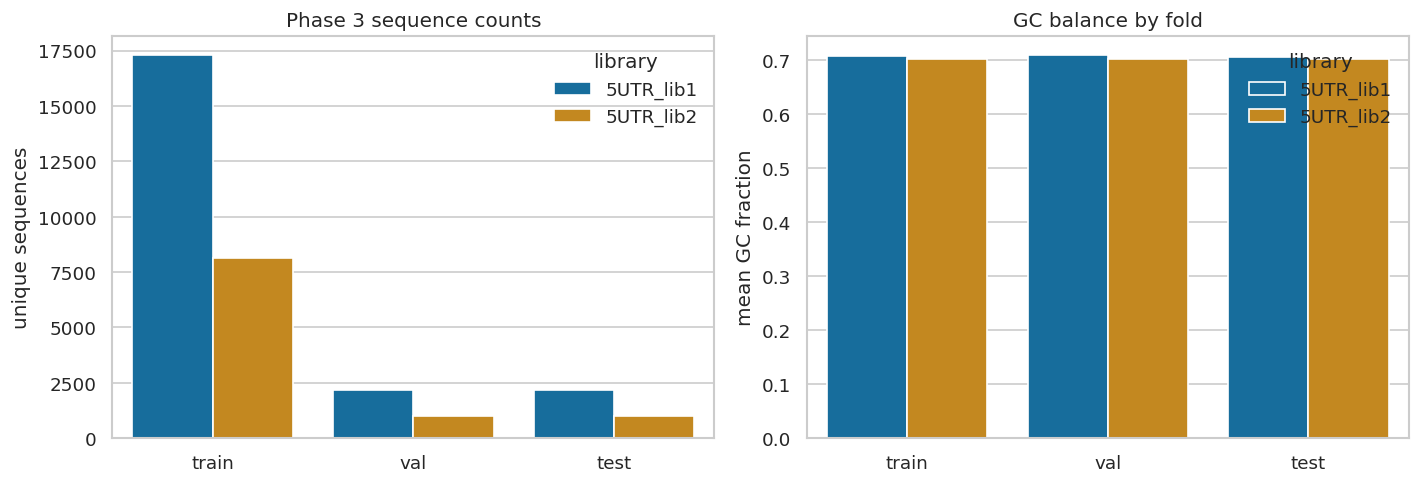

In [4]:
data = pd.read_csv(DATA_PATH)
sequence_manifest = pd.read_csv(MANIFEST_PATH)
dataset_manifest = read_json_optional(DATASET_MANIFEST_JSON)

for head in HEAD_ORDER:
    data[head] = pd.to_numeric(data[head], errors="coerce")
if "gc_fraction" not in data.columns:
    data["gc_fraction"] = data["seq"].astype(str).str.upper().map(lambda s: (s.count("G") + s.count("C")) / len(s) if len(s) else np.nan)

split_audit = (
    data.groupby(["library", "fold"], observed=True)
    .agg(
        n_sequences=("seq", "nunique"),
        gc_mean=("gc_fraction", "mean"),
        gc_std=("gc_fraction", "std"),
        mean_activity=(HEAD_ORDER[0], lambda s: np.nan),
    )
    .reset_index()
)
activity_means = (
    data.groupby(["library", "fold"], observed=True)[HEAD_ORDER]
    .mean()
    .add_prefix("mean_")
    .reset_index()
)
split_audit = split_audit.drop(columns=["mean_activity"]).merge(activity_means, on=["library", "fold"], how="left")
split_audit["fold"] = pd.Categorical(split_audit["fold"], categories=SPLIT_ORDER, ordered=True)
split_audit = split_audit.sort_values(["library", "fold"]).reset_index(drop=True)
save_df(split_audit, "phase3_dataset_split_audit.csv")

overview = pd.DataFrame([
    {
        "phase3_rows": len(data),
        "phase3_unique_sequences": data["seq"].nunique(),
        "libraries": compact_values(data["library"]),
        "folds": compact_values(data["fold"]),
        "heads": compact_values(HEAD_ORDER),
        "dataset_manifest_rows": dataset_manifest.get("combined_rows") or dataset_manifest.get("n_rows"),
        "dataset_overlap_policy": dataset_manifest.get("overlap_audit", {}).get("overlap_policy"),
        "lib2_split_seed": dataset_manifest.get("lib2_split_seed"),
        "data_path": str(DATA_PATH),
    }
])
display(overview)
display(split_audit.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_df = split_audit.copy()
sns.barplot(data=plot_df, x="fold", y="n_sequences", hue="library", ax=axes[0])
axes[0].set_title("Phase 3 sequence counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("unique sequences")
axes[0].legend(title="library", frameon=False)

sns.barplot(data=plot_df, x="fold", y="gc_mean", hue="library", ax=axes[1])
axes[1].set_title("GC balance by fold")
axes[1].set_xlabel("")
axes[1].set_ylabel("mean GC fraction")
axes[1].legend(title="library", frameon=False)
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase3_dataset_split_audit.png", bbox_inches="tight")
plt.show()


In [5]:
if PHASE2_SPLIT_MANIFEST_PATH.exists():
    phase2_manifest = pd.read_csv(PHASE2_SPLIT_MANIFEST_PATH)
    phase2_seq_col = "seq_upper" if "seq_upper" in phase2_manifest.columns else "seq"
    phase3_lib2 = sequence_manifest[sequence_manifest["library"].eq("5UTR_lib2")].copy()
    phase3_lib2["seq_upper"] = phase3_lib2["seq"].astype(str).str.upper()
    phase2_check = phase2_manifest[[phase2_seq_col, "split"]].rename(columns={phase2_seq_col: "seq_upper", "split": "phase2_split"})
    phase3_check = phase3_lib2[["seq_upper", "fold"]].rename(columns={"fold": "phase3_split"})
    split_compare = phase2_check.merge(phase3_check, on="seq_upper", how="outer", indicator=True)
    split_overlap_summary = pd.DataFrame([
        {
            "phase2_sequences": phase2_check["seq_upper"].nunique(),
            "phase3_lib2_sequences": phase3_check["seq_upper"].nunique(),
            "overlap_sequences": int(split_compare["_merge"].eq("both").sum()),
            "same_split_among_overlap": int((split_compare["_merge"].eq("both") & split_compare["phase2_split"].eq(split_compare["phase3_split"])).sum()),
        }
    ])
    split_crosstab = pd.crosstab(
        split_compare.loc[split_compare["_merge"].eq("both"), "phase2_split"],
        split_compare.loc[split_compare["_merge"].eq("both"), "phase3_split"],
        dropna=False,
    )
    save_df(split_compare, "phase3_vs_phase2_lib2_sequence_split_compare.csv")
    display(Markdown("Phase 2 versus Phase 3 Lib2 split alignment. Different splits mean Phase 2 and Phase 3 Lib2 numbers are comparable as held-out Lib2 diagnostics, but not paired on exactly the same validation/test sequence identities."))
    display(split_overlap_summary)
    display(split_crosstab)
else:
    phase2_manifest = pd.DataFrame()
    display(Markdown(f"Phase 2 Lib2 split manifest not found at `{PHASE2_SPLIT_MANIFEST_PATH}`."))


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_vs_phase2_lib2_sequence_split_compare.csv


Phase 2 versus Phase 3 Lib2 split alignment. Different splits mean Phase 2 and Phase 3 Lib2 numbers are comparable as held-out Lib2 diagnostics, but not paired on exactly the same validation/test sequence identities.

,phase2_sequences,phase3_lib2_sequences,overlap_sequences,same_split_among_overlap
0,10174,10174,10174,10174


phase3_split,test,train,val
phase2_split,,,
test,1017,0,0
train,0,8140,0
val,0,0,1017


## Load Phase 3 HPO Runs

The local W&B summaries provide final and post-best-checkpoint evaluation metrics. The copied `selection.json` files provide the best checkpoint monitor value and checkpoint path for each run.


In [6]:
runs_raw, summaries = load_local_wandb_runs(LOCAL_WANDB_DIR, PROJECT)
selection = load_selection_table(BEST_CHECKPOINT_ROOT)

if runs_raw.empty:
    raise RuntimeError(f"No Phase 3 runs found in {LOCAL_WANDB_DIR}")
if selection.empty:
    raise RuntimeError(f"No selection.json files found in {BEST_CHECKPOINT_ROOT}")

runs = runs_raw.merge(selection, on="run_id", how="left", suffixes=("", "_selection"))
runs["has_best_torch_checkpoint"] = runs["best_torch_checkpoint"].map(lambda p: Path(str(p)).exists() if pd.notna(p) else False)
runs["has_local_run_checkpoint"] = runs["run_id"].map(lambda rid: (RUN_ROOT / str(rid) / "checkpoints").exists())
runs = to_numeric_columns(runs, [PRIMARY_SELECTION_METRIC, "best_epoch", "current_epoch", "epoch", "trainer/global_step", "lr", "weight_decay", "dropout_p"])

metric_long, eval_wide, per_head_eval = extract_eval_tables(summaries)
if not eval_wide.empty:
    eval_wide = eval_wide.merge(
        runs[["run_id", PRIMARY_SELECTION_METRIC, "best_epoch", "lr", "weight_decay", "dropout_p", "batch_size", "optimizer", "scheduler", "stem_channels", "head_hidden_channels"]],
        on="run_id",
        how="left",
    )

save_df(runs, "phase3_hpo_run_summary.csv")
save_df(eval_wide, "phase3_hpo_library_eval_wide.csv")
save_df(per_head_eval, "phase3_hpo_per_head_eval_long.csv")

run_overview = pd.DataFrame([
    {
        "local_wandb_runs": len(runs_raw),
        "runs_with_selection_json": selection["run_id"].nunique(),
        "runs_with_best_torch_checkpoint": int(runs["has_best_torch_checkpoint"].sum()),
        "runs_with_library_eval_metrics": metric_long["run_id"].nunique() if not metric_long.empty else 0,
        "sweep_ids": compact_values(runs.get("wandb_sweep_id", pd.Series(dtype=object))),
        "optimizers": compact_values(runs["optimizer"]),
        "schedulers": compact_values(runs["scheduler"]),
        "batch_sizes": compact_values(runs["batch_size"]),
        "lr_range": f"{runs['lr'].min():.3g} - {runs['lr'].max():.3g}",
        "weight_decay_range": f"{runs['weight_decay'].min():.3g} - {runs['weight_decay'].max():.3g}",
    }
])
display(run_overview)

display(runs[[
    "run_id", PRIMARY_SELECTION_METRIC, "selection_metric_name", "best_epoch", "current_epoch", "optimizer", "scheduler", "lr", "weight_decay", "dropout_p", "batch_size", "stem_channels", "block_kernel_size", "head_hidden_channels", "has_best_torch_checkpoint",
]].sort_values(PRIMARY_SELECTION_METRIC, ascending=False).head(12).round(6))


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_hpo_run_summary.csv
wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_hpo_library_eval_wide.csv
wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_hpo_per_head_eval_long.csv


,local_wandb_runs,runs_with_selection_json,runs_with_best_torch_checkpoint,runs_with_library_eval_metrics,sweep_ids,optimizers,schedulers,batch_sizes,lr_range,weight_decay_range
0,64,64,64,64,swwsl6az,"Adam, AdamW","CosineAnnealingWarmRestarts, None","256, 512, 1024",0.000251 - 0.00205,1.06e-05 - 0.00242


,run_id,selection_metric_value,selection_metric_name,best_epoch,current_epoch,optimizer,scheduler,lr,weight_decay,dropout_p,batch_size,stem_channels,block_kernel_size,head_hidden_channels,has_best_torch_checkpoint
61,4eq96xxd,0.517562,epoch_end_val_pearson_r2,31,86.0,AdamW,CosineAnnealingWarmRestarts,0.000703,0.000071,0.393325,512,163,5,232,True
25,elg4xha7,0.515241,epoch_end_val_pearson_r2,46,101.0,AdamW,CosineAnnealingWarmRestarts,0.000495,0.000100,0.393814,1024,125,5,360,True
33,7z6csbkb,0.514579,epoch_end_val_pearson_r2,48,103.0,AdamW,CosineAnnealingWarmRestarts,0.000467,0.000049,0.379092,512,149,5,265,True
55,ggw9ss5a,0.512275,epoch_end_val_pearson_r2,95,150.0,AdamW,CosineAnnealingWarmRestarts,0.000300,0.000023,0.399645,512,164,5,256,True
58,oujnk20u,0.512220,epoch_end_val_pearson_r2,47,102.0,AdamW,CosineAnnealingWarmRestarts,0.000286,0.000192,0.397883,512,86,7,356,True
22,kvyfi2nw,0.512108,epoch_end_val_pearson_r2,29,84.0,AdamW,CosineAnnealingWarmRestarts,0.000937,0.001771,0.388149,1024,140,5,281,True
57,12o1td07,0.511603,epoch_end_val_pearson_r2,25,80.0,AdamW,CosineAnnealingWarmRestarts,0.000753,0.000019,0.370379,256,147,5,383,True
30,9nhsztu4,0.511593,epoch_end_val_pearson_r2,56,111.0,AdamW,CosineAnnealingWarmRestarts,0.000450,0.000058,0.399721,1024,160,5,211,True
27,aahefkaw,0.511367,epoch_end_val_pearson_r2,62,117.0,AdamW,CosineAnnealingWarmRestarts,0.000397,0.000305,0.393112,256,141,5,354,True
13,vs6a5o7i,0.511075,epoch_end_val_pearson_r2,23,78.0,AdamW,CosineAnnealingWarmRestarts,0.000588,0.000817,0.395904,1024,163,9,325,True


## Primary Selection and Alternative Readouts

The Phase 3 sweep was configured to maximize `epoch_end_val_pearson_r2`. Because this is a combined validation monitor, the notebook also reports post-hoc top runs by Lib1-only, Lib2-only, combined, paper-style average activity Pearson, and mean per-head Pearson. Those readouts can be useful for model promotion discussions, but they are not the original HPO objective.


In [7]:
leaderboard = runs.dropna(subset=[PRIMARY_SELECTION_METRIC]).sort_values(PRIMARY_SELECTION_METRIC, ascending=False).reset_index(drop=True)
leaderboard["selection_rank"] = np.arange(1, len(leaderboard) + 1)
selected_run = leaderboard.iloc[0].to_dict()
SELECTED_RUN_ID = str(selected_run["run_id"])
SELECTED_CHECKPOINT_DIR = Path(str(selected_run["best_checkpoint_dir"]))
SELECTED_TORCH_CHECKPOINT = Path(str(selected_run["best_torch_checkpoint"]))

leaderboard_cols = [
    "selection_rank", "run_id", PRIMARY_SELECTION_METRIC, "best_epoch", "current_epoch", "optimizer", "scheduler", "lr", "weight_decay", "dropout_p", "batch_size", "stem_channels", "stem_kernel_size", "block_kernel_size", "head_hidden_channels", "source_artifact_path", "best_torch_checkpoint",
]
leaderboard_export = leaderboard[[c for c in leaderboard_cols if c in leaderboard.columns]].copy()
save_df(leaderboard_export, "phase3_hpo_leaderboard.csv")

display(Markdown(f"Primary selected Phase 3 run: `{SELECTED_RUN_ID}` by `{PRIMARY_MONITOR_NAME}` = `{selected_run[PRIMARY_SELECTION_METRIC]:.6f}` at best epoch `{int(selected_run['best_epoch'])}`."))
display(leaderboard_export.head(20).round(6))

selected_eval = eval_wide[eval_wide["run_id"].eq(SELECTED_RUN_ID)].copy()
eval_display_cols = [
    "split", "library", "n_sequences", "loss", "pearson_r2", "cod_r2", "mean_per_head_pearson", "average_activity_pearson", "average_activity_spearman", "flattened_activity_pearson", "flattened_activity_spearman",
]
display(Markdown("Selected run library-aware metrics."))
display(selected_eval[[c for c in eval_display_cols if c in selected_eval.columns]].sort_values(["split", "library"]).round(5))

ranking_specs = [
    ("val", "combined", "average_activity_pearson"),
    ("val", "5UTR_lib1", "average_activity_pearson"),
    ("val", "5UTR_lib2", "average_activity_pearson"),
    ("test", "combined", "average_activity_pearson"),
    ("test", "5UTR_lib2", "average_activity_pearson"),
    ("test", "5UTR_lib1", "average_activity_pearson"),
]
alt_rows = []
for split, library, metric in ranking_specs:
    if metric not in eval_wide.columns:
        continue
    sub = eval_wide[eval_wide["split"].eq(split) & eval_wide["library"].eq(library)].dropna(subset=[metric]).sort_values(metric, ascending=False)
    if sub.empty:
        continue
    top = sub.iloc[0]
    alt_rows.append({
        "ranking_metric": metric,
        "split": split,
        "library": library,
        "top_run_id": top["run_id"],
        "top_value": top[metric],
        "is_primary_selected_run": top["run_id"] == SELECTED_RUN_ID,
        "primary_selected_value": float(selected_eval[(selected_eval["split"].eq(split)) & (selected_eval["library"].eq(library))][metric].iloc[0]) if len(selected_eval[(selected_eval["split"].eq(split)) & (selected_eval["library"].eq(library))]) and metric in selected_eval.columns else np.nan,
    })
alt_ranking = pd.DataFrame(alt_rows)
save_df(alt_ranking, "phase3_hpo_alternative_metric_winners.csv")
display(Markdown("Post-hoc winners by paper-style average-activity Pearson. These are diagnostics beside the configured HPO winner."))
display(alt_ranking.round(6))


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_hpo_leaderboard.csv


Primary selected Phase 3 run: `4eq96xxd` by `epoch_end_val_pearson_r2` = `0.517562` at best epoch `31`.

,selection_rank,run_id,selection_metric_value,best_epoch,current_epoch,optimizer,scheduler,lr,weight_decay,dropout_p,batch_size,stem_channels,stem_kernel_size,block_kernel_size,head_hidden_channels,source_artifact_path,best_torch_checkpoint
0,1,4eq96xxd,0.517562,31,86.0,AdamW,CosineAnnealingWarmRestarts,0.000703,0.000071,0.393325,512,163,5,5,232,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
1,2,elg4xha7,0.515241,46,101.0,AdamW,CosineAnnealingWarmRestarts,0.000495,0.000100,0.393814,1024,125,5,5,360,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
2,3,7z6csbkb,0.514579,48,103.0,AdamW,CosineAnnealingWarmRestarts,0.000467,0.000049,0.379092,512,149,5,5,265,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
3,4,ggw9ss5a,0.512275,95,150.0,AdamW,CosineAnnealingWarmRestarts,0.000300,0.000023,0.399645,512,164,5,5,256,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
4,5,oujnk20u,0.512220,47,102.0,AdamW,CosineAnnealingWarmRestarts,0.000286,0.000192,0.397883,512,86,5,7,356,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
5,6,kvyfi2nw,0.512108,29,84.0,AdamW,CosineAnnealingWarmRestarts,0.000937,0.001771,0.388149,1024,140,5,5,281,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
6,7,12o1td07,0.511603,25,80.0,AdamW,CosineAnnealingWarmRestarts,0.000753,0.000019,0.370379,256,147,5,5,383,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
7,8,9nhsztu4,0.511593,56,111.0,AdamW,CosineAnnealingWarmRestarts,0.000450,0.000058,0.399721,1024,160,5,5,211,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
8,9,aahefkaw,0.511367,62,117.0,AdamW,CosineAnnealingWarmRestarts,0.000397,0.000305,0.393112,256,141,5,5,354,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...
9,10,vs6a5o7i,0.511075,23,78.0,AdamW,CosineAnnealingWarmRestarts,0.000588,0.000817,0.395904,1024,163,5,9,325,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...


Selected run library-aware metrics.

,split,library,n_sequences,loss,pearson_r2,cod_r2,mean_per_head_pearson,average_activity_pearson,average_activity_spearman,flattened_activity_pearson,flattened_activity_spearman
86,train,combined,25427.0,0.32886,0.67510,0.67112,0.82172,0.94109,0.90335,0.81907,0.75567
84,train,5UTR_lib1,17287.0,0.23406,0.75611,0.74988,0.86670,0.95040,0.91393,0.86449,0.79194
85,train,5UTR_lib2,8140.0,0.53021,0.53397,0.53297,0.72829,0.91856,0.88553,0.73588,0.68810
89,val,combined,3178.0,0.51080,0.51757,0.51745,0.71890,0.81988,0.76014,0.71427,0.64252
87,val,5UTR_lib1,2161.0,0.40187,0.60814,0.60421,0.77627,0.84617,0.78008,0.77362,0.68013
88,val,5UTR_lib2,1017.0,0.74224,0.36259,0.35455,0.59978,0.76094,0.72373,0.60333,0.56832
83,test,combined,3177.0,0.49941,0.49205,0.49181,0.70097,0.81251,0.75195,0.69772,0.62463
81,test,5UTR_lib1,2160.0,0.39266,0.56633,0.56508,0.74962,0.82801,0.76207,0.74527,0.65893
82,test,5UTR_lib2,1017.0,0.72613,0.37540,0.36798,0.61057,0.78230,0.73197,0.61864,0.55970


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_hpo_alternative_metric_winners.csv


Post-hoc winners by paper-style average-activity Pearson. These are diagnostics beside the configured HPO winner.

,ranking_metric,split,library,top_run_id,top_value,is_primary_selected_run,primary_selected_value
0,average_activity_pearson,val,combined,4eq96xxd,0.819881,True,0.819881
1,average_activity_pearson,val,5UTR_lib1,4eq96xxd,0.846174,True,0.846174
2,average_activity_pearson,val,5UTR_lib2,4eq96xxd,0.760944,True,0.760944
3,average_activity_pearson,test,combined,4eq96xxd,0.812508,True,0.812508
4,average_activity_pearson,test,5UTR_lib2,iqwmf1q4,0.786898,False,0.782300
5,average_activity_pearson,test,5UTR_lib1,glfv0bla,0.828097,False,0.828013


## HPO Diagnostics

This section checks whether the sweep found a consistent region of hyperparameter space, whether top runs are clustered by optimizer/scheduler/batch size, and whether selected checkpoints stopped early or near the epoch cap.


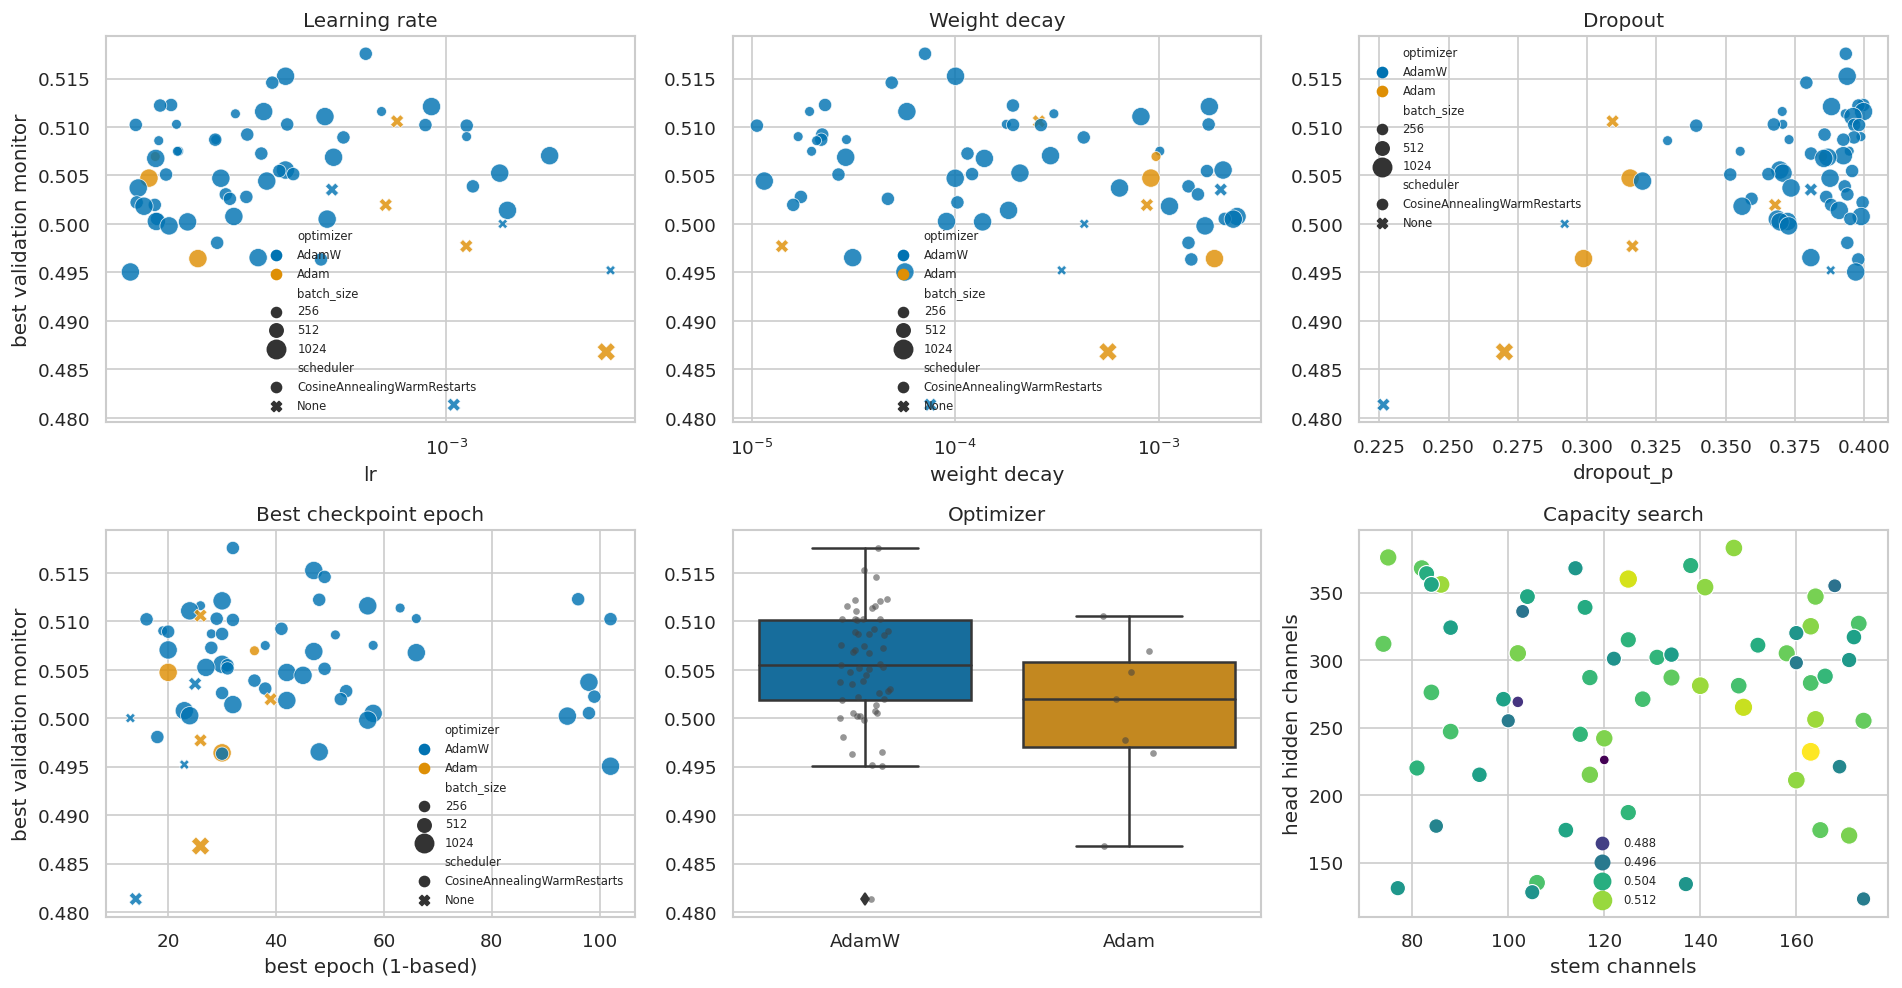

wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_top_hyperparameter_settings.csv


,selection_rank,run_id,selection_metric_value,best_epoch,optimizer,scheduler,lr,weight_decay,dropout_p,batch_size,stem_channels,stem_kernel_size,block_kernel_size,head_hidden_channels
0,1,4eq96xxd,0.517562,31,AdamW,CosineAnnealingWarmRestarts,0.000703,0.000071,0.393325,512,163,5,5,232
1,2,elg4xha7,0.515241,46,AdamW,CosineAnnealingWarmRestarts,0.000495,0.000100,0.393814,1024,125,5,5,360
2,3,7z6csbkb,0.514579,48,AdamW,CosineAnnealingWarmRestarts,0.000467,0.000049,0.379092,512,149,5,5,265
3,4,ggw9ss5a,0.512275,95,AdamW,CosineAnnealingWarmRestarts,0.000300,0.000023,0.399645,512,164,5,5,256
4,5,oujnk20u,0.512220,47,AdamW,CosineAnnealingWarmRestarts,0.000286,0.000192,0.397883,512,86,5,7,356
5,6,kvyfi2nw,0.512108,29,AdamW,CosineAnnealingWarmRestarts,0.000937,0.001771,0.388149,1024,140,5,5,281
6,7,12o1td07,0.511603,25,AdamW,CosineAnnealingWarmRestarts,0.000753,0.000019,0.370379,256,147,5,5,383
7,8,9nhsztu4,0.511593,56,AdamW,CosineAnnealingWarmRestarts,0.000450,0.000058,0.399721,1024,160,5,5,211
8,9,aahefkaw,0.511367,62,AdamW,CosineAnnealingWarmRestarts,0.000397,0.000305,0.393112,256,141,5,5,354
9,10,vs6a5o7i,0.511075,23,AdamW,CosineAnnealingWarmRestarts,0.000588,0.000817,0.395904,1024,163,5,9,325


In [8]:
plot_runs = leaderboard.copy()
plot_runs["best_epoch_1based"] = plot_runs["best_epoch"] + 1
plot_runs["optimizer_scheduler"] = plot_runs["optimizer"].astype(str) + " / " + plot_runs["scheduler"].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(16, 8.4))
axes = axes.ravel()

sns.scatterplot(data=plot_runs, x="lr", y=PRIMARY_SELECTION_METRIC, hue="optimizer", style="scheduler", size="batch_size", sizes=(35, 120), alpha=0.82, ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Learning rate")
axes[0].set_xlabel("lr")
axes[0].set_ylabel("best validation monitor")

sns.scatterplot(data=plot_runs, x="weight_decay", y=PRIMARY_SELECTION_METRIC, hue="optimizer", style="scheduler", size="batch_size", sizes=(35, 120), alpha=0.82, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Weight decay")
axes[1].set_xlabel("weight decay")
axes[1].set_ylabel("")

sns.scatterplot(data=plot_runs, x="dropout_p", y=PRIMARY_SELECTION_METRIC, hue="optimizer", style="scheduler", size="batch_size", sizes=(35, 120), alpha=0.82, ax=axes[2])
axes[2].set_title("Dropout")
axes[2].set_xlabel("dropout_p")
axes[2].set_ylabel("")

sns.scatterplot(data=plot_runs, x="best_epoch_1based", y=PRIMARY_SELECTION_METRIC, hue="optimizer", style="scheduler", size="batch_size", sizes=(35, 120), alpha=0.82, ax=axes[3])
axes[3].set_title("Best checkpoint epoch")
axes[3].set_xlabel("best epoch (1-based)")
axes[3].set_ylabel("best validation monitor")

sns.boxplot(data=plot_runs, x="optimizer", y=PRIMARY_SELECTION_METRIC, ax=axes[4])
sns.stripplot(data=plot_runs, x="optimizer", y=PRIMARY_SELECTION_METRIC, color="0.25", alpha=0.55, size=4, ax=axes[4])
axes[4].set_title("Optimizer")
axes[4].set_xlabel("")
axes[4].set_ylabel("")

sns.scatterplot(data=plot_runs, x="stem_channels", y="head_hidden_channels", hue=PRIMARY_SELECTION_METRIC, size=PRIMARY_SELECTION_METRIC, sizes=(35, 130), palette="viridis", ax=axes[5])
axes[5].set_title("Capacity search")
axes[5].set_xlabel("stem channels")
axes[5].set_ylabel("head hidden channels")

for ax in axes[:4]:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(frameon=False, fontsize=7, loc="best")
axes[5].legend(frameon=False, fontsize=7, loc="best")
plt.tight_layout()
plt.savefig(PLOT_DIR / "phase3_hpo_hyperparameter_diagnostics.png", bbox_inches="tight")
plt.show()

top_n = 12
hp_summary = plot_runs.head(top_n)[[
    "selection_rank", "run_id", PRIMARY_SELECTION_METRIC, "best_epoch", "optimizer", "scheduler", "lr", "weight_decay", "dropout_p", "batch_size", "stem_channels", "stem_kernel_size", "block_kernel_size", "head_hidden_channels",
]].copy()
save_df(hp_summary, "phase3_top_hyperparameter_settings.csv")
display(hp_summary.round(6))


## Library-Aware Validation and Test Behavior

Phase 3 training intentionally mixes Lib1 and Lib2, so a single combined metric can hide library-specific tradeoffs. These plots and tables use the extra post-training metrics logged by `train_wandb_log.py` for each library slice.


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_val_test_library_metric_pairs.csv


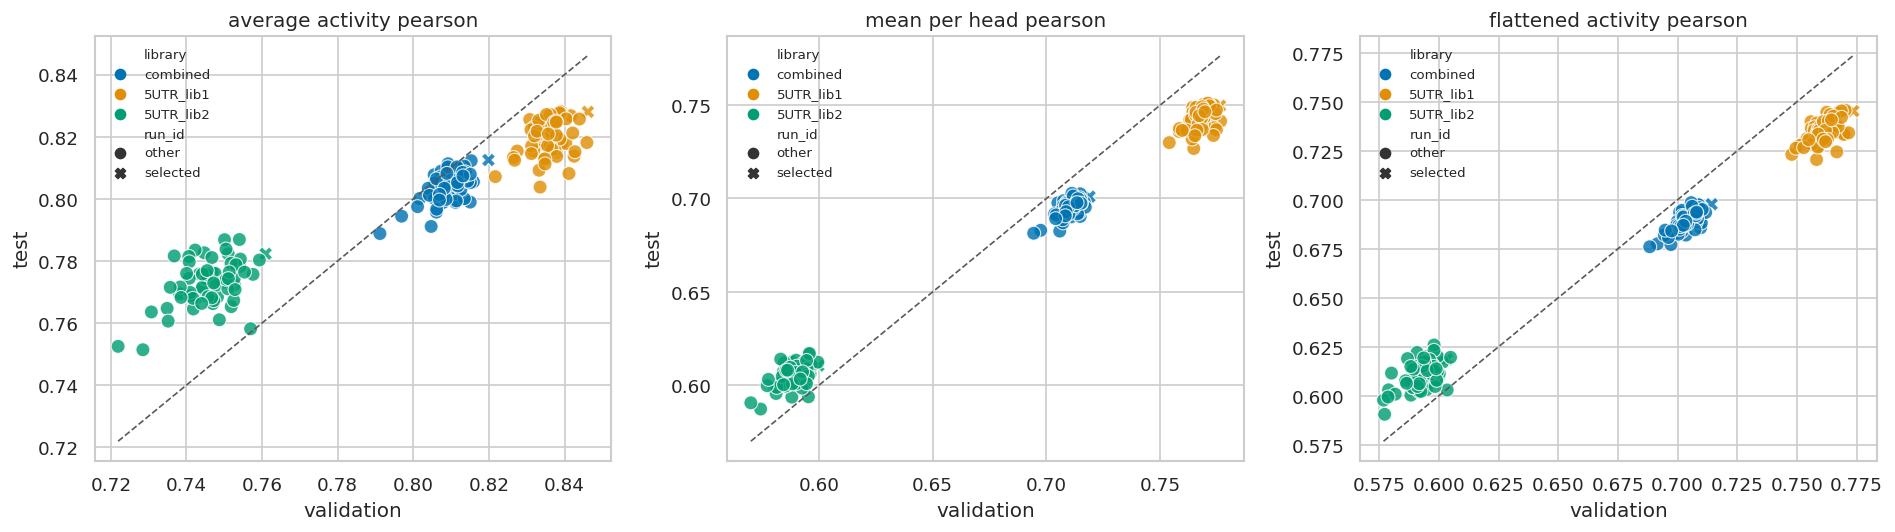

Selected run validation/test metrics by library.

,split,library,n_sequences,loss,pearson_r2,cod_r2,mean_per_head_pearson,average_activity_pearson,average_activity_spearman,flattened_activity_pearson,flattened_activity_spearman
89,val,combined,3178.0,0.51080,0.51757,0.51745,0.71890,0.81988,0.76014,0.71427,0.64252
87,val,5UTR_lib1,2161.0,0.40187,0.60814,0.60421,0.77627,0.84617,0.78008,0.77362,0.68013
88,val,5UTR_lib2,1017.0,0.74224,0.36259,0.35455,0.59978,0.76094,0.72373,0.60333,0.56832
83,test,combined,3177.0,0.49941,0.49205,0.49181,0.70097,0.81251,0.75195,0.69772,0.62463
81,test,5UTR_lib1,2160.0,0.39266,0.56633,0.56508,0.74962,0.82801,0.76207,0.74527,0.65893
82,test,5UTR_lib2,1017.0,0.72613,0.37540,0.36798,0.61057,0.78230,0.73197,0.61864,0.55970


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_val_test_generalization_gap_summary.csv


,metric,library,n_runs,val_mean,test_mean,test_minus_val_mean,selected_val,selected_test,selected_test_minus_val
0,average_activity_pearson,combined,64,0.80921,0.80422,-0.00499,0.81988,0.81251,-0.00737
1,average_activity_pearson,5UTR_lib1,64,0.83595,0.81975,-0.01620,0.84617,0.82801,-0.01816
2,average_activity_pearson,5UTR_lib2,64,0.74597,0.77281,0.02684,0.76094,0.78230,0.02136
3,mean_per_head_pearson,combined,64,0.71037,0.69497,-0.01540,0.71890,0.70097,-0.01793
4,mean_per_head_pearson,5UTR_lib1,64,0.76739,0.74243,-0.02496,0.77627,0.74962,-0.02665
5,mean_per_head_pearson,5UTR_lib2,64,0.58909,0.60482,0.01573,0.59978,0.61057,0.01079
6,flattened_activity_pearson,combined,64,0.70365,0.68912,-0.01453,0.71427,0.69772,-0.01655
7,flattened_activity_pearson,5UTR_lib1,64,0.76148,0.73557,-0.02590,0.77362,0.74527,-0.02835
8,flattened_activity_pearson,5UTR_lib2,64,0.59314,0.61087,0.01773,0.60333,0.61864,0.01532


In [9]:
def val_test_pairs(frame, metric):
    val = frame[frame["split"].eq("val")][["run_id", "library", metric]].rename(columns={metric: f"val_{metric}"})
    test = frame[frame["split"].eq("test")][["run_id", "library", metric]].rename(columns={metric: f"test_{metric}"})
    out = val.merge(test, on=["run_id", "library"], how="inner")
    out = out.merge(runs[["run_id", PRIMARY_SELECTION_METRIC, "best_epoch", "lr", "weight_decay", "dropout_p", "optimizer", "scheduler"]], on="run_id", how="left")
    out[f"test_minus_val_{metric}"] = out[f"test_{metric}"] - out[f"val_{metric}"]
    return out

pair_metrics = ["average_activity_pearson", "mean_per_head_pearson", "flattened_activity_pearson"]
val_test_tables = []
for metric in pair_metrics:
    if metric in eval_wide.columns:
        tmp = val_test_pairs(eval_wide, metric)
        tmp["metric"] = metric
        val_test_tables.append(tmp)
val_test = pd.concat(val_test_tables, ignore_index=True) if val_test_tables else pd.DataFrame()
save_df(val_test, "phase3_val_test_library_metric_pairs.csv")

if not val_test.empty:
    fig, axes = plt.subplots(1, len(pair_metrics), figsize=(5.3 * len(pair_metrics), 4.6), sharey=False)
    if len(pair_metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, pair_metrics):
        sub = val_test[val_test["metric"].eq(metric)].copy()
        if sub.empty:
            ax.set_axis_off()
            continue
        sns.scatterplot(
            data=sub,
            x=f"val_{metric}",
            y=f"test_{metric}",
            hue="library",
            style=sub["run_id"].eq(SELECTED_RUN_ID).map({True: "selected", False: "other"}),
            s=70,
            alpha=0.82,
            ax=ax,
        )
        lo = np.nanmin([sub[f"val_{metric}"].min(), sub[f"test_{metric}"].min()])
        hi = np.nanmax([sub[f"val_{metric}"].max(), sub[f"test_{metric}"].max()])
        ax.plot([lo, hi], [lo, hi], color="0.35", linestyle="--", linewidth=1)
        ax.set_title(metric.replace("_", " "))
        ax.set_xlabel("validation")
        ax.set_ylabel("test")
        ax.legend(frameon=False, fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "phase3_val_vs_test_library_metrics.png", bbox_inches="tight")
    plt.show()

selected_test_val = selected_eval[selected_eval["split"].isin(["val", "test"])].copy()
display(Markdown("Selected run validation/test metrics by library."))
display(selected_test_val[[c for c in eval_display_cols if c in selected_test_val.columns]].sort_values(["split", "library"]).round(5))

gap_rows = []
for metric in pair_metrics:
    if metric not in eval_wide.columns:
        continue
    pairs = val_test_pairs(eval_wide, metric)
    for library in LIBRARY_ORDER:
        sub = pairs[pairs["library"].eq(library)].copy()
        if sub.empty:
            continue
        selected_sub = sub[sub["run_id"].eq(SELECTED_RUN_ID)]
        gap_rows.append({
            "metric": metric,
            "library": library,
            "n_runs": len(sub),
            "val_mean": sub[f"val_{metric}"].mean(),
            "test_mean": sub[f"test_{metric}"].mean(),
            "test_minus_val_mean": sub[f"test_minus_val_{metric}"].mean(),
            "selected_val": selected_sub[f"val_{metric}"].iloc[0] if len(selected_sub) else np.nan,
            "selected_test": selected_sub[f"test_{metric}"].iloc[0] if len(selected_sub) else np.nan,
            "selected_test_minus_val": selected_sub[f"test_minus_val_{metric}"].iloc[0] if len(selected_sub) else np.nan,
        })
gap_summary = pd.DataFrame(gap_rows)
save_df(gap_summary, "phase3_val_test_generalization_gap_summary.csv")
display(gap_summary.round(5))


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_selected_run_per_head_pearson.csv


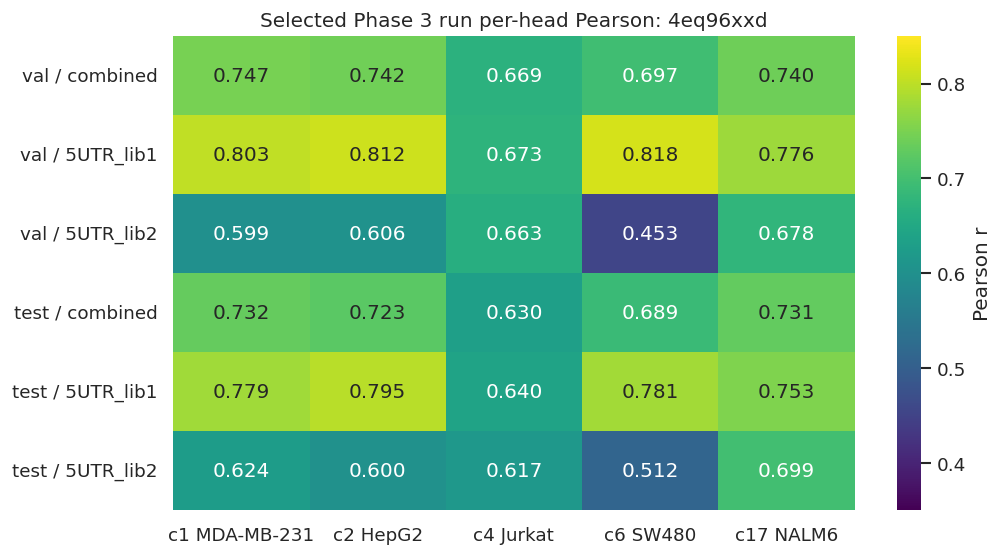

head_label,c1 MDA-MB-231,c2 HepG2,c4 Jurkat,c6 SW480,c17 NALM6
slice,,,,,
val / combined,0.7468,0.7420,0.6685,0.6972,0.7400
val / 5UTR_lib1,0.8025,0.8124,0.6728,0.8176,0.7760
val / 5UTR_lib2,0.5991,0.6057,0.6628,0.4533,0.6780
test / combined,0.7323,0.7226,0.6302,0.6891,0.7305
test / 5UTR_lib1,0.7787,0.7954,0.6399,0.7813,0.7527
test / 5UTR_lib2,0.6243,0.6005,0.6168,0.5119,0.6994


In [10]:
selected_head_eval = per_head_eval[
    per_head_eval["run_id"].eq(SELECTED_RUN_ID)
    & per_head_eval["split"].isin(["val", "test"])
    & per_head_eval["metric_family"].eq("pearson")
].copy()
selected_head_eval["slice"] = selected_head_eval["split"].astype(str) + " / " + selected_head_eval["library"].astype(str)
selected_head_eval["head_label"] = selected_head_eval["head"].astype(str).map(HEAD_LABELS)
save_df(selected_head_eval, "phase3_selected_run_per_head_pearson.csv")

if not selected_head_eval.empty:
    heat = selected_head_eval.pivot_table(index="slice", columns="head_label", values="value", aggfunc="first")
    ordered_slices = [f"{split} / {library}" for split in ["val", "test"] for library in LIBRARY_ORDER]
    heat = heat.reindex([s for s in ordered_slices if s in heat.index])
    heat = heat[[HEAD_LABELS[h] for h in HEAD_ORDER if HEAD_LABELS[h] in heat.columns]]
    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis", vmin=0.35, vmax=0.85, ax=ax, cbar_kws={"label": "Pearson r"})
    ax.set_title(f"Selected Phase 3 run per-head Pearson: {SELECTED_RUN_ID}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "phase3_selected_run_per_head_pearson_heatmap.png", bbox_inches="tight")
    plt.show()
    display(heat.round(4))
else:
    display(Markdown("No per-head evaluation metrics were found for the selected run."))


## Phase 2 Versus Phase 3 Scorecard

The Phase 2 notebook selected fine-tuned models by Lib2 validation average-activity Pearson. Phase 3 selected scratch models by the configured combined validation monitor. The scorecard below keeps those selection rules explicit and compares held-out Lib2, Lib1 retention, and combined Phase 3 slices.


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase2_vs_phase3_scorecard.csv


Phase 2 selected model by Lib2 validation average activity: `finetuned_1mmy39ku__seed7__full__hlr3p0e04__blr1p0e05__scaler_pretrained_lib1_train`

,model_branch,model_label,selection_basis,reported_split,library,n_sequences,average_activity_pearson,mean_per_head_pearson,flattened_activity_pearson,average_activity_spearman
0,Phase 1 Lib1 pretrained 1mmy39ku,pretrained_1mmy39ku,original Lib1 pretrained baseline,lib2_val,5UTR_lib2,1017.0,0.69229,0.53644,0.52399,0.62937
1,Phase 1 Lib1 pretrained 1mmy39ku,pretrained_1mmy39ku,original Lib1 pretrained baseline,lib2_test,5UTR_lib2,1017.0,0.71428,0.54842,0.53803,0.64196
2,Phase 1 Lib1 pretrained 1mmy39ku,pretrained_1mmy39ku,original Lib1 pretrained baseline,lib1_test_retention,5UTR_lib1,2160.0,0.83309,0.75496,0.74967,0.76161
3,Phase 2 Lib2 fine-tuned 1mmy39ku,finetuned_1mmy39ku__seed7__full__hlr3p0e04__bl...,Lib2 validation average-activity Pearson,lib2_val,5UTR_lib2,1017.0,0.76260,0.60295,0.60846,0.71847
4,Phase 2 Lib2 fine-tuned 1mmy39ku,finetuned_1mmy39ku__seed7__full__hlr3p0e04__bl...,Lib2 validation average-activity Pearson,lib2_test,5UTR_lib2,1017.0,0.78653,0.61859,0.62472,0.73567
5,Phase 2 Lib2 fine-tuned 1mmy39ku,finetuned_1mmy39ku__seed7__full__hlr3p0e04__bl...,Lib2 validation average-activity Pearson,lib1_test_retention,5UTR_lib1,2160.0,0.81888,0.73537,0.70157,0.74136
6,Phase 3 Lib1+Lib2 scratch,phase3_scratch_4eq96xxd,epoch_end_val_pearson_r2,lib2_val,5UTR_lib2,1017.0,0.76094,0.59978,0.60333,0.72373
7,Phase 3 Lib1+Lib2 scratch,phase3_scratch_4eq96xxd,epoch_end_val_pearson_r2,lib2_test,5UTR_lib2,1017.0,0.78230,0.61057,0.61864,0.73197
8,Phase 3 Lib1+Lib2 scratch,phase3_scratch_4eq96xxd,epoch_end_val_pearson_r2,lib1_test_retention,5UTR_lib1,2160.0,0.82801,0.74962,0.74527,0.76207
9,Phase 3 Lib1+Lib2 scratch,phase3_scratch_4eq96xxd,epoch_end_val_pearson_r2,combined_val,combined,3178.0,0.81988,0.71890,0.71427,0.76014


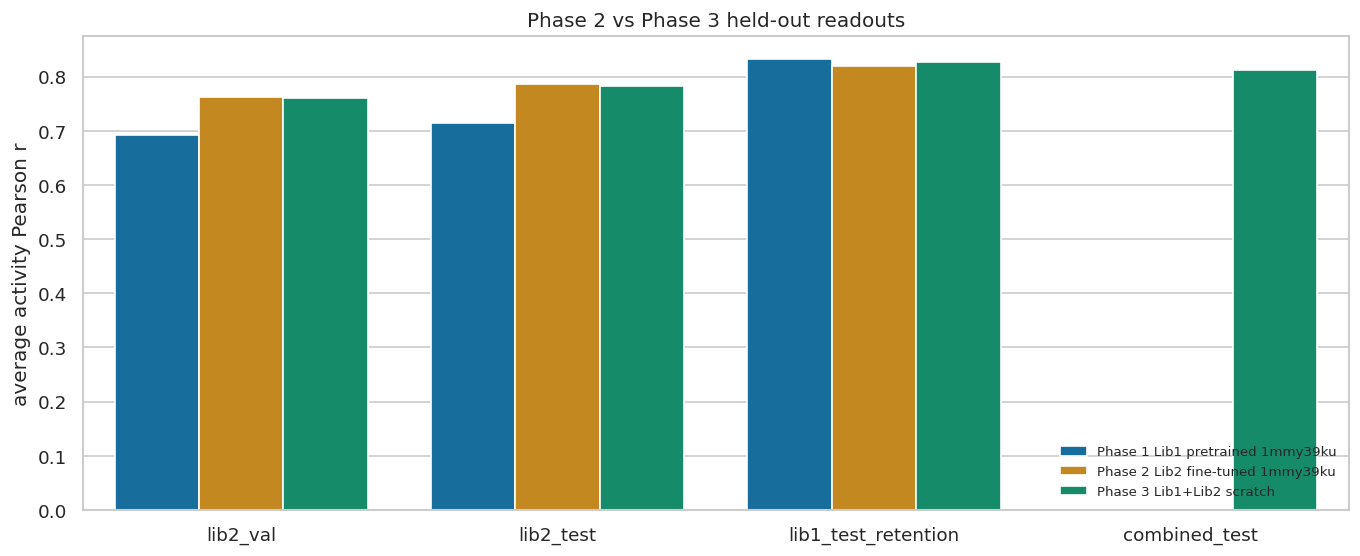

Top Phase 2 validation checkpoints for context.

,model_label,run_seed,unfreeze_scope,head_lr,backbone_lr,average_activity_pearson,mean_per_head_pearson,flattened_activity_pearson
18,finetuned_1mmy39ku__seed7__full__hlr3p0e04__bl...,7.0,full,0.0003,0.00001,0.76260,0.60295,0.60846
60,finetuned_1mmy39ku__seed13__full__hlr3p0e04__b...,13.0,full,0.0003,0.00001,0.76213,0.60236,0.60804
39,finetuned_1mmy39ku__seed11__full__hlr3p0e04__b...,11.0,full,0.0003,0.00001,0.76136,0.60181,0.60724
15,finetuned_1mmy39ku__seed7__full__hlr1p0e04__bl...,7.0,full,0.0001,0.00001,0.76071,0.60012,0.60604
57,finetuned_1mmy39ku__seed13__full__hlr1p0e04__b...,13.0,full,0.0001,0.00001,0.76030,0.59968,0.60590
36,finetuned_1mmy39ku__seed11__full__hlr1p0e04__b...,11.0,full,0.0001,0.00001,0.76028,0.60017,0.60628
54,finetuned_1mmy39ku__seed13__last_stage_plus_he...,13.0,last_stage_plus_head,0.0003,0.00001,0.74602,0.58963,0.59274
12,finetuned_1mmy39ku__seed7__last_stage_plus_hea...,7.0,last_stage_plus_head,0.0003,0.00001,0.74524,0.58917,0.59243


In [11]:
def selected_phase2_model(phase2_summary):
    if phase2_summary.empty:
        return None, pd.DataFrame()
    ft = phase2_summary[~phase2_summary["model_label"].eq(BASELINE_LABEL)].copy()
    val = ft[ft["split"].eq("lib2_val")].sort_values("average_activity_pearson", ascending=False)
    if val.empty:
        return None, pd.DataFrame()
    return str(val.iloc[0]["model_label"]), val


def phase2_row(summary, model_label, split, branch_label, selection_basis):
    sub = summary[summary["model_label"].eq(model_label) & summary["split"].eq(split)].copy()
    if sub.empty:
        return None
    row = sub.iloc[0].to_dict()
    return {
        "model_branch": branch_label,
        "model_label": model_label,
        "selection_basis": selection_basis,
        "reported_split": split,
        "library": "5UTR_lib2" if "lib2" in split else "5UTR_lib1",
        "n_sequences": row.get("n_sequences"),
        "average_activity_pearson": row.get("average_activity_pearson"),
        "mean_per_head_pearson": row.get("mean_per_head_pearson"),
        "flattened_activity_pearson": row.get("flattened_activity_pearson"),
        "average_activity_spearman": row.get("average_activity_spearman"),
    }


def phase3_row(eval_frame, run_id, split, library, branch_label, reported_split, selection_basis):
    sub = eval_frame[eval_frame["run_id"].eq(run_id) & eval_frame["split"].eq(split) & eval_frame["library"].eq(library)].copy()
    if sub.empty:
        return None
    row = sub.iloc[0].to_dict()
    return {
        "model_branch": branch_label,
        "model_label": f"phase3_scratch_{run_id}",
        "selection_basis": selection_basis,
        "reported_split": reported_split,
        "library": library,
        "n_sequences": row.get("n_sequences"),
        "average_activity_pearson": row.get("average_activity_pearson"),
        "mean_per_head_pearson": row.get("mean_per_head_pearson"),
        "flattened_activity_pearson": row.get("flattened_activity_pearson"),
        "average_activity_spearman": row.get("average_activity_spearman"),
    }

if PHASE2_SUMMARY_PATH.exists():
    phase2_summary = pd.read_csv(PHASE2_SUMMARY_PATH)
    phase2_selected_label, phase2_val_ranking = selected_phase2_model(phase2_summary)
    compare_rows = []
    for split in ["lib2_val", "lib2_test", "lib1_test_retention"]:
        row = phase2_row(phase2_summary, BASELINE_LABEL, split, "Phase 1 Lib1 pretrained 1mmy39ku", "original Lib1 pretrained baseline")
        if row:
            compare_rows.append(row)
    if phase2_selected_label:
        for split in ["lib2_val", "lib2_test", "lib1_test_retention"]:
            row = phase2_row(phase2_summary, phase2_selected_label, split, "Phase 2 Lib2 fine-tuned 1mmy39ku", "Lib2 validation average-activity Pearson")
            if row:
                compare_rows.append(row)
    for split, library, reported_split in [
        ("val", "5UTR_lib2", "lib2_val"),
        ("test", "5UTR_lib2", "lib2_test"),
        ("test", "5UTR_lib1", "lib1_test_retention"),
        ("val", "combined", "combined_val"),
        ("test", "combined", "combined_test"),
    ]:
        row = phase3_row(eval_wide, SELECTED_RUN_ID, split, library, "Phase 3 Lib1+Lib2 scratch", reported_split, PRIMARY_MONITOR_NAME)
        if row:
            compare_rows.append(row)
    phase_comparison = pd.DataFrame(compare_rows)
    save_df(phase_comparison, "phase2_vs_phase3_scorecard.csv")
    display(Markdown(f"Phase 2 selected model by Lib2 validation average activity: `{phase2_selected_label}`"))
    display(phase_comparison.round(5))

    plot_compare = phase_comparison[phase_comparison["reported_split"].isin(["lib2_val", "lib2_test", "lib1_test_retention", "combined_test"])].copy()
    fig, ax = plt.subplots(figsize=(11.5, 4.8))
    sns.barplot(data=plot_compare, x="reported_split", y="average_activity_pearson", hue="model_branch", ax=ax)
    ax.set_title("Phase 2 vs Phase 3 held-out readouts")
    ax.set_xlabel("")
    ax.set_ylabel("average activity Pearson r")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "phase2_vs_phase3_average_activity_scorecard.png", bbox_inches="tight")
    plt.show()

    if phase2_val_ranking is not None and not phase2_val_ranking.empty:
        display(Markdown("Top Phase 2 validation checkpoints for context."))
        display(phase2_val_ranking[["model_label", "run_seed", "unfreeze_scope", "head_lr", "backbone_lr", "average_activity_pearson", "mean_per_head_pearson", "flattened_activity_pearson"]].head(8).round(5))
else:
    phase2_summary = pd.DataFrame()
    phase2_selected_label = None
    phase_comparison = pd.DataFrame()
    display(Markdown(f"Phase 2 comparison table not found at `{PHASE2_SUMMARY_PATH}`."))


## In-House FivePrime External Check

This section scores the selected Phase 3 scratch checkpoint on exact-length in-house `FivePrime` candidates and correlates predictions with `RNA/DNA` and `log2_RNA_DNA`. Per the plan, this is an external deployment readout only. Do not use these metrics to change the HPO winner unless a separate untouched in-house validation/test policy is written first.


In [12]:
RUN_INHOUSE_SCORING = True
OVERWRITE_INHOUSE_PREDICTIONS = False
INHOUSE_BATCH_SIZE = int(os.environ.get("BODA_INHOUSE_BATCH_SIZE", "512"))
INHOUSE_PREDICTION_PATH = PLOT_DIR / f"phase3_selected_{SELECTED_RUN_ID}_inhouse_fiveprime_predictions.csv"
INHOUSE_METRICS_PATH = PLOT_DIR / f"phase3_selected_{SELECTED_RUN_ID}_inhouse_fiveprime_metrics.csv"


def load_inhouse_fiveprime(path=INHOUSE_FIVEPRIME_PATH):
    df = pd.read_csv(path).copy()
    df["candidate_id"] = np.arange(len(df))
    df["candidate_seq"] = df["FivePrime"].astype(str).str.upper()
    df["candidate_len"] = df["candidate_seq"].str.len()
    df["valid_dna"] = df["candidate_seq"].str.fullmatch("[ACGTN]+").fillna(False)
    df["exact_50nt"] = df["candidate_len"].eq(50)
    df["scoreable_exact"] = df["valid_dna"] & df["exact_50nt"]
    df["RNA_DNA"] = pd.to_numeric(df["RNA/DNA"], errors="coerce")
    df["log2_RNA_DNA"] = np.log2(df["RNA_DNA"].where(df["RNA_DNA"].gt(0)))
    if "number_of_barcodes" in df.columns:
        df["number_of_barcodes"] = pd.to_numeric(df["number_of_barcodes"], errors="coerce")
    else:
        df["number_of_barcodes"] = np.nan
    return df


def inhouse_metric_rows(pred_df, model_label):
    rows = []
    subsets = {
        "all_exact_finite": pred_df[pred_df["scoreable_exact"]].copy(),
        "barcode_min_8": pred_df[pred_df["scoreable_exact"] & pred_df["number_of_barcodes"].ge(8)].copy(),
    }
    pred_cols = [f"pred_activity_{head}" for head in HEAD_ORDER] + ["pred_average_activity"]
    for subset_name, subset in subsets.items():
        for target in ["RNA_DNA", "log2_RNA_DNA"]:
            for pred_col in pred_cols:
                frame = subset[[target, pred_col]].replace([np.inf, -np.inf], np.nan).dropna()
                rows.append({
                    "model_label": model_label,
                    "subset": subset_name,
                    "target": target,
                    "predictor": pred_col,
                    "n": len(frame),
                    "pearson": pearson_np(frame[pred_col], frame[target]) if len(frame) else np.nan,
                    "pearson_r2": pearson_np(frame[pred_col], frame[target]) ** 2 if len(frame) >= 2 and not np.isnan(pearson_np(frame[pred_col], frame[target])) else np.nan,
                    "cod_r2": cod_r2(frame[target], frame[pred_col]) if len(frame) else np.nan,
                    "spearman": spearman_np(frame[pred_col], frame[target]) if len(frame) else np.nan,
                    "mse": float(((frame[target] - frame[pred_col]) ** 2).mean()) if len(frame) else np.nan,
                    "mae": float((frame[target] - frame[pred_col]).abs().mean()) if len(frame) else np.nan,
                    "rmse": float(np.sqrt(((frame[target] - frame[pred_col]) ** 2).mean())) if len(frame) else np.nan,
                })
    return pd.DataFrame(rows)


def hparams_to_dict(obj):
    if isinstance(obj, dict):
        return dict(obj)
    return vars(obj)


def import_boda_prediction_stack():
    try:
        import torch
        from torch.utils.data import DataLoader, TensorDataset
        if str(REPO_ROOT / "src") not in sys.path:
            sys.path.insert(0, str(REPO_ROOT / "src"))
        import boda
        from boda.common import utils as boda_utils
        return torch, DataLoader, TensorDataset, boda, boda_utils, None
    except Exception as exc:
        return None, None, None, None, None, exc


def load_torch_checkpoint_model(checkpoint_path, device):
    torch, DataLoader, TensorDataset, boda, boda_utils, import_error = import_boda_prediction_stack()
    if import_error is not None:
        raise import_error
    checkpoint = torch.load(str(checkpoint_path), map_location=device)
    model_module = checkpoint["model_module"]
    model_cls = getattr(boda.model, model_module)
    model_hparams = hparams_to_dict(checkpoint["model_hparams"])
    model = model_cls(**model_hparams)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    model.to(device)
    data_hparams = hparams_to_dict(checkpoint.get("data_hparams", {}))
    return model, model_hparams, data_hparams, DataLoader, TensorDataset, boda_utils, torch


def predict_boda_sequences(model, seqs, batch_size, device, DataLoader, TensorDataset, boda_utils, torch):
    x = torch.stack([boda_utils.dna2tensor(str(seq).upper()) for seq in seqs])
    ds = TensorDataset(x)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, drop_last=False)
    preds = []
    with torch.no_grad():
        for (batch_x,) in dl:
            y = model(batch_x.to(device)).detach().cpu()
            preds.append(y)
    return torch.cat(preds, dim=0).numpy()


def score_selected_phase3_inhouse():
    if not SELECTED_TORCH_CHECKPOINT.exists():
        raise FileNotFoundError(SELECTED_TORCH_CHECKPOINT)
    inhouse = load_inhouse_fiveprime(INHOUSE_FIVEPRIME_PATH)
    scoreable = inhouse[inhouse["scoreable_exact"]].copy()
    if scoreable.empty:
        raise RuntimeError("No exact 50-nt valid FivePrime candidates were scoreable.")
    if INHOUSE_PREDICTION_PATH.exists() and not OVERWRITE_INHOUSE_PREDICTIONS:
        pred_df = pd.read_csv(INHOUSE_PREDICTION_PATH)
    else:
        torch, _, _, _, _, import_error = import_boda_prediction_stack()
        if import_error is not None:
            raise import_error
        device = os.environ.get("BODA_DEVICE") or ("cuda" if torch.cuda.is_available() else "cpu")
        model, model_hparams, data_hparams, DataLoader, TensorDataset, boda_utils, torch = load_torch_checkpoint_model(SELECTED_TORCH_CHECKPOINT, device)
        pred_norm = predict_boda_sequences(model, scoreable["candidate_seq"].tolist(), INHOUSE_BATCH_SIZE, device, DataLoader, TensorDataset, boda_utils, torch)
        pred_norm = pd.DataFrame(pred_norm, columns=HEAD_ORDER, index=scoreable.index)
        train_stats = data[data["fold"].eq("train")][HEAD_ORDER].agg(["mean", "std"]).T
        train_stats["std"] = train_stats["std"].replace(0, 1.0)
        pred_raw = pred_norm.mul(train_stats["std"], axis=1).add(train_stats["mean"], axis=1)

        pred_df = inhouse.copy()
        for head in HEAD_ORDER:
            pred_df[f"pred_activity_{head}"] = np.nan
            pred_df.loc[scoreable.index, f"pred_activity_{head}"] = pred_raw[head].values
        pred_df["pred_average_activity"] = pred_df[[f"pred_activity_{h}" for h in HEAD_ORDER]].mean(axis=1)
        pred_df["phase3_run_id"] = SELECTED_RUN_ID
        pred_df["phase3_checkpoint_path"] = str(SELECTED_TORCH_CHECKPOINT)
        pred_df.to_csv(INHOUSE_PREDICTION_PATH, index=False)
    metrics = inhouse_metric_rows(pred_df, f"phase3_scratch_{SELECTED_RUN_ID}")
    metrics.to_csv(INHOUSE_METRICS_PATH, index=False)
    return pred_df, metrics

if RUN_INHOUSE_SCORING:
    try:
        inhouse_predictions, inhouse_metrics = score_selected_phase3_inhouse()
        print("wrote", INHOUSE_PREDICTION_PATH)
        print("wrote", INHOUSE_METRICS_PATH)
        display(inhouse_predictions[["scoreable_exact", "candidate_len", "valid_dna", "RNA_DNA", "log2_RNA_DNA", "pred_average_activity"]].describe(include="all"))
        display(inhouse_metrics[
            inhouse_metrics["target"].eq("log2_RNA_DNA")
            & inhouse_metrics["predictor"].isin(["pred_average_activity", "pred_activity_c1", "pred_activity_c2", "pred_activity_c4", "pred_activity_c6", "pred_activity_c17"])
        ].sort_values(["subset", "pearson"], ascending=[True, False]).round(5))
    except Exception as exc:
        inhouse_predictions = pd.DataFrame()
        inhouse_metrics = pd.DataFrame()
        display(Markdown(f"Skipped Phase 3 in-house prediction because `{type(exc).__name__}: {exc}`. Run this notebook in `boda_env` with the BODA stack importable to enable this section."))
else:
    inhouse_predictions = pd.DataFrame()
    inhouse_metrics = pd.DataFrame()
    display(Markdown("`RUN_INHOUSE_SCORING` is False; skipped checkpoint inference on in-house FivePrime candidates."))


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_selected_4eq96xxd_inhouse_fiveprime_predictions.csv
wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_selected_4eq96xxd_inhouse_fiveprime_metrics.csv


,scoreable_exact,candidate_len,valid_dna,RNA_DNA,log2_RNA_DNA,pred_average_activity
count,8461,8461.000000,8461,8461.000000,8461.000000,8331.000000
unique,2,NaN,2,NaN,NaN,NaN
top,True,NaN,True,NaN,NaN,NaN
freq,8331,NaN,8460,NaN,NaN,NaN
mean,NaN,49.974589,NaN,6.591129,2.575669,2.397094
std,NaN,0.600781,NaN,3.448845,0.641403,0.167095
min,NaN,1.000000,NaN,0.166667,-2.584963,1.708645
25%,NaN,50.000000,NaN,4.646465,2.216133,2.277456
50%,NaN,50.000000,NaN,5.976190,2.579226,2.442314
75%,NaN,50.000000,NaN,7.670213,2.939267,2.530360


,model_label,subset,target,predictor,n,pearson,pearson_r2,cod_r2,spearman,mse,mae,rmse
10,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_activity_c17,8331,0.14873,0.02212,-0.11093,0.18254,0.45831,0.50554,0.67699
9,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_activity_c6,8331,0.14855,0.02207,-0.09034,0.18623,0.44982,0.49990,0.67068
6,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_activity_c1,8331,0.14575,0.02124,-0.04603,0.19461,0.43153,0.48777,0.65691
11,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_average_activity,8331,0.13956,0.01948,-0.07350,0.18447,0.44287,0.49527,0.66548
8,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_activity_c4,8331,0.12516,0.01566,-0.09556,0.16690,0.45197,0.50172,0.67229
7,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_activity_c2,8331,0.11311,0.01279,-0.04870,0.17313,0.43264,0.48868,0.65775
22,phase3_scratch_4eq96xxd,barcode_min_8,log2_RNA_DNA,pred_activity_c17,1797,0.19358,0.03747,-0.21308,0.23204,0.24725,0.38814,0.49724
21,phase3_scratch_4eq96xxd,barcode_min_8,log2_RNA_DNA,pred_activity_c6,1797,0.19038,0.03624,-0.17057,0.23224,0.23858,0.38126,0.48845
18,phase3_scratch_4eq96xxd,barcode_min_8,log2_RNA_DNA,pred_activity_c1,1797,0.18483,0.03416,-0.08618,0.24174,0.22138,0.36602,0.47051
23,phase3_scratch_4eq96xxd,barcode_min_8,log2_RNA_DNA,pred_average_activity,1797,0.17924,0.03213,-0.13767,0.23310,0.23188,0.37530,0.48154


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase2_vs_phase3_inhouse_fiveprime_average_activity_metrics.csv


,model_branch,model_label,subset,target,predictor,n,pearson,spearman,pearson_r2
0,Phase 1 Lib1 pretrained 1mmy39ku,pretrained_1mmy39ku,all_exact_finite,log2_RNA_DNA,pred_average_activity,8331,0.14361,0.18104,0.02062
1,Phase 1 Lib1 pretrained 1mmy39ku,pretrained_1mmy39ku,barcode_min_8,log2_RNA_DNA,pred_average_activity,1797,0.17946,0.22673,0.03221
2,Phase 2 Lib2 fine-tuned 1mmy39ku,finetuned_1mmy39ku__seed7__full__hlr3p0e04__bl...,all_exact_finite,log2_RNA_DNA,pred_average_activity,8331,0.13761,0.17167,0.01894
3,Phase 2 Lib2 fine-tuned 1mmy39ku,finetuned_1mmy39ku__seed7__full__hlr3p0e04__bl...,barcode_min_8,log2_RNA_DNA,pred_average_activity,1797,0.16708,0.20723,0.02792
4,Phase 3 Lib1+Lib2 scratch,phase3_scratch_4eq96xxd,all_exact_finite,log2_RNA_DNA,pred_average_activity,8331,0.13956,0.18447,0.01948
5,Phase 3 Lib1+Lib2 scratch,phase3_scratch_4eq96xxd,barcode_min_8,log2_RNA_DNA,pred_average_activity,1797,0.17924,0.23310,0.03213


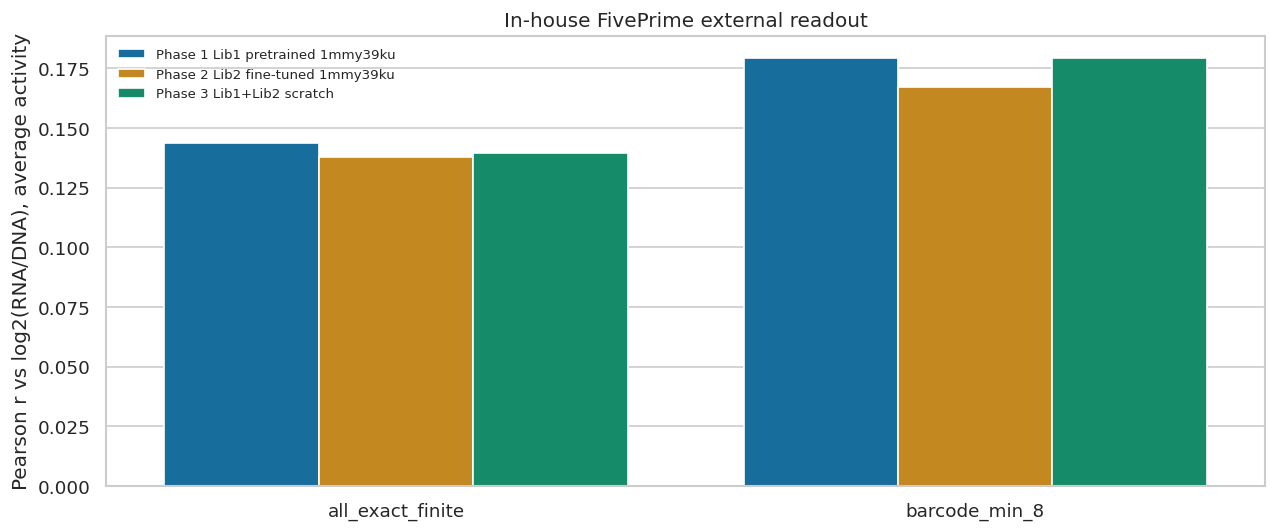

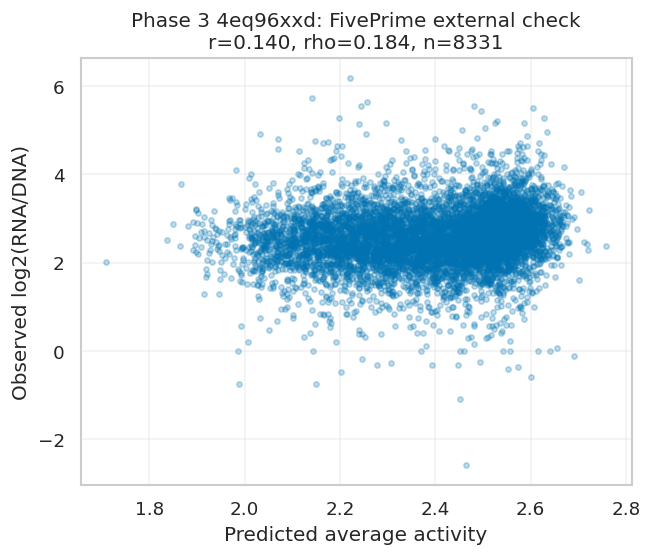

In [13]:
if not inhouse_metrics.empty:
    phase3_inhouse_plot = inhouse_metrics[
        inhouse_metrics["target"].eq("log2_RNA_DNA")
        & inhouse_metrics["predictor"].eq("pred_average_activity")
    ].copy()
    compare_inhouse = phase3_inhouse_plot.copy()
    compare_inhouse["model_branch"] = "Phase 3 Lib1+Lib2 scratch"

    if PHASE2_INHOUSE_PATH.exists() and phase2_selected_label:
        phase2_inhouse = pd.read_csv(PHASE2_INHOUSE_PATH)
        phase2_keep = phase2_inhouse[
            phase2_inhouse["target"].eq("log2_RNA_DNA")
            & phase2_inhouse["predictor"].eq("pred_average_activity")
            & phase2_inhouse["model_label"].isin([BASELINE_LABEL, phase2_selected_label])
        ].copy()
        phase2_keep = phase2_keep.drop_duplicates(["model_label", "subset", "target", "predictor"])
        phase2_keep["model_branch"] = phase2_keep["model_label"].map({
            BASELINE_LABEL: "Phase 1 Lib1 pretrained 1mmy39ku",
            phase2_selected_label: "Phase 2 Lib2 fine-tuned 1mmy39ku",
        })
        compare_inhouse = pd.concat([phase2_keep, compare_inhouse], ignore_index=True, sort=False)

    save_df(compare_inhouse, "phase2_vs_phase3_inhouse_fiveprime_average_activity_metrics.csv")
    display(compare_inhouse[["model_branch", "model_label", "subset", "target", "predictor", "n", "pearson", "spearman", "pearson_r2"]].round(5))

    fig, ax = plt.subplots(figsize=(10.8, 4.6))
    sns.barplot(data=compare_inhouse, x="subset", y="pearson", hue="model_branch", ax=ax)
    ax.set_title("In-house FivePrime external readout")
    ax.set_xlabel("")
    ax.set_ylabel("Pearson r vs log2(RNA/DNA), average activity")
    ax.legend(frameon=False, fontsize=8, loc="best")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "phase2_vs_phase3_inhouse_fiveprime_average_activity.png", bbox_inches="tight")
    plt.show()

    if not inhouse_predictions.empty:
        scoreable = inhouse_predictions[inhouse_predictions["scoreable_exact"]].replace([np.inf, -np.inf], np.nan).dropna(subset=["log2_RNA_DNA", "pred_average_activity"])
        fig, ax = plt.subplots(figsize=(5.6, 4.8))
        ax.scatter(scoreable["pred_average_activity"], scoreable["log2_RNA_DNA"], s=10, alpha=0.25)
        r = pearson_np(scoreable["pred_average_activity"], scoreable["log2_RNA_DNA"])
        rho = spearman_np(scoreable["pred_average_activity"], scoreable["log2_RNA_DNA"])
        ax.set_title(f"Phase 3 {SELECTED_RUN_ID}: FivePrime external check\nr={r:.3f}, rho={rho:.3f}, n={len(scoreable)}")
        ax.set_xlabel("Predicted average activity")
        ax.set_ylabel("Observed log2(RNA/DNA)")
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(PLOT_DIR / "phase3_selected_inhouse_fiveprime_scatter.png", bbox_inches="tight")
        plt.show()
else:
    display(Markdown("No Phase 3 in-house metrics are available yet."))


## Decision Notes and Output Index

Use this final table as the compact promotion packet. Promotion should consider the configured Phase 3 validation winner, Lib2 test performance, Lib1 retention, and the in-house external check together. If Phase 3 does not clearly beat Phase 2 on the operational criteria, keep Phase 2 as the stronger branch and treat Phase 3 as a useful scratch baseline.


In [14]:
selected_summary_rows = []
for split, library in [("val", "combined"), ("test", "combined"), ("test", "5UTR_lib1"), ("test", "5UTR_lib2")]:
    sub = selected_eval[selected_eval["split"].eq(split) & selected_eval["library"].eq(library)]
    if sub.empty:
        continue
    row = sub.iloc[0]
    selected_summary_rows.append({
        "run_id": SELECTED_RUN_ID,
        "selection_metric_name": selected_run.get("selection_metric_name"),
        "selection_metric_value": selected_run.get(PRIMARY_SELECTION_METRIC),
        "best_epoch": selected_run.get("best_epoch"),
        "split": split,
        "library": library,
        "average_activity_pearson": row.get("average_activity_pearson"),
        "mean_per_head_pearson": row.get("mean_per_head_pearson"),
        "flattened_activity_pearson": row.get("flattened_activity_pearson"),
        "average_activity_spearman": row.get("average_activity_spearman"),
        "n_sequences": row.get("n_sequences"),
        "best_torch_checkpoint": str(SELECTED_TORCH_CHECKPOINT),
        "source_artifact_path": selected_run.get("source_artifact_path"),
        "run_url": selected_run.get("run_url"),
    })
selected_summary = pd.DataFrame(selected_summary_rows)
save_df(selected_summary, "phase3_selected_run_summary.csv")
display(selected_summary.round(5))

metadata = {
    "notebook": str(NOTEBOOK_DIR / "hani_utr5_lib1_lib2_phase3_scratch_hpo_analysis_may2026.ipynb"),
    "created_for": "Phase 3 Hani 5UTR Lib1+Lib2 scratch HPO post-run analysis",
    "project": PROJECT,
    "primary_selection_metric": PRIMARY_MONITOR_NAME,
    "selected_run_id": SELECTED_RUN_ID,
    "selected_torch_checkpoint": str(SELECTED_TORCH_CHECKPOINT),
    "data_path": str(DATA_PATH),
    "manifest_path": str(MANIFEST_PATH),
    "phase2_summary_path": str(PHASE2_SUMMARY_PATH),
    "inhouse_fiveprime_path": str(INHOUSE_FIVEPRIME_PATH),
    "head_order": HEAD_ORDER,
    "selection_policy": "Use Phase 3 configured combined validation monitor; use Lib2 test, Lib1 retention, and in-house FivePrime only as diagnostics.",
}
(PLOT_DIR / "phase3_hpo_analysis_metadata.json").write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n")

outputs = sorted(PLOT_DIR.glob("*"))
print(f"Wrote/available outputs in {PLOT_DIR}:")
for path in outputs:
    print("-", path.name)


wrote /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026/phase3_selected_run_summary.csv


,run_id,selection_metric_name,selection_metric_value,best_epoch,split,library,average_activity_pearson,mean_per_head_pearson,flattened_activity_pearson,average_activity_spearman,n_sequences,best_torch_checkpoint,source_artifact_path,run_url
0,4eq96xxd,epoch_end_val_pearson_r2,0.51756,31,val,combined,0.81988,0.71890,0.71427,0.76014,3178.0,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,https://wandb.ai/minhangxu1998-baylor-college-...
1,4eq96xxd,epoch_end_val_pearson_r2,0.51756,31,test,combined,0.81251,0.70097,0.69772,0.75195,3177.0,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,https://wandb.ai/minhangxu1998-baylor-college-...
2,4eq96xxd,epoch_end_val_pearson_r2,0.51756,31,test,5UTR_lib1,0.82801,0.74962,0.74527,0.76207,2160.0,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,https://wandb.ai/minhangxu1998-baylor-college-...
3,4eq96xxd,epoch_end_val_pearson_r2,0.51756,31,test,5UTR_lib2,0.78230,0.61057,0.61864,0.73197,1017.0,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,/home/minhang/synBio_AL/boda2_EU/src/learn/loc...,https://wandb.ai/minhangxu1998-baylor-college-...


Wrote/available outputs in /home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr5_lib1_lib2_phase3_scratch_hpo_may2026:
- phase2_vs_phase3_average_activity_scorecard.png
- phase2_vs_phase3_inhouse_fiveprime_average_activity.png
- phase2_vs_phase3_inhouse_fiveprime_average_activity_metrics.csv
- phase2_vs_phase3_scorecard.csv
- phase3_dataset_split_audit.csv
- phase3_dataset_split_audit.png
- phase3_hpo_alternative_metric_winners.csv
- phase3_hpo_analysis_metadata.json
- phase3_hpo_hyperparameter_diagnostics.png
- phase3_hpo_leaderboard.csv
- phase3_hpo_library_eval_wide.csv
- phase3_hpo_per_head_eval_long.csv
- phase3_hpo_run_summary.csv
- phase3_selected_4eq96xxd_inhouse_fiveprime_metrics.csv
- phase3_selected_4eq96xxd_inhouse_fiveprime_predictions.csv
- phase3_selected_inhouse_fiveprime_scatter.png
- phase3_selected_run_per_head_pearson.csv
- phase3_selected_run_per_head_pearson_heatmap.png
- phase3_selected_run_summary.csv
- ph